# EmotiSpeech — Pipeline Completo

Este notebook ejecuta el pipeline de extremo a extremo y ofrece visualizaciones en cada paso:

| Paso | Qué hace | Script |
|---|---|---|
| 1 | Auditar etiquetas con el modelo SER (audeering) | `auditar_etiquetas_ia.py` |
| 2 | Localizar el mejor segmento de 10 s por audio | `segmentar_rescate.py` |
| 3 | Explorar el dataset localizado | — |
| 4 | Entrenar 6 clasificadores + evaluación honesta | `entrenar_procesado.py` |
| 5 | Explorar embeddings (PCA / t-SNE) | — |
| 6 | Matriz de confusión y recall por clase | — |
| 7 | Generar datos del dashboard | `generar_datos_decisiones.py` etc. |

**Celdas pesadas** (requieren el encoder ~1.2 GB) chequean si el output ya existe y lo saltan si es así. Para forzar re-ejecución: poner `FORCE_RERUN = True` en la celda de setup.

## Setup

In [5]:
import os, sys, subprocess, shutil
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, recall_score
from sklearn.model_selection import LeaveOneOut
from IPython.display import display

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white", "axes.spines.top": False, "axes.spines.right": False})
sns.set_theme(style="whitegrid", font_scale=1.05)

# ── Raíz del proyecto (un nivel arriba de notebooks/) ──────────────────────
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "scripts"))

from config import ACTIVE_CLASSES, DASHBOARD_HOLDOUT, DASHBOARD_HOLDOUT_SEED
from exportar_modelos import MODEL_SPECS

# ── Paleta de colores por emoción ──────────────────────────────────────────
PALETTE = {
    "Enojo":        "#ef4444",
    "Feliz":        "#f59e0b",
    "Tranquilidad": "#06b6d4",
    "Tristeza":     "#8b5cf6",
}

# ── Paths ──────────────────────────────────────────────────────────────────
OUTPUTS      = ROOT / "outputs"
DATA_DIR     = ROOT / "data" / "AUDIOS MACHINE LEARNING"
PROC_DIR     = ROOT / "data" / "procesado"
SEG_DIR      = OUTPUTS / "mejores_segmentos"
AUDIT_CSV    = OUTPUTS / "audios_sospechosos_ia.csv"
SEG_CSV      = OUTPUTS / "mejores_segmentos.csv"
EMBED_NPZ    = OUTPUTS / "proc_embeddings.npz"
METRICS_JSON = OUTPUTS / "model_metrics.json"

# ── Control de re-ejecución ────────────────────────────────────────────────
FORCE_RERUN = False   # True = re-corre aunque ya existan los outputs

def run(script, *args, output_check=None):
    """Corre un script del proyecto. Saltea si output_check existe y FORCE_RERUN=False."""
    if output_check and Path(output_check).exists() and not FORCE_RERUN:
        print(f"✓ Ya existe: {Path(output_check).name}  —  saltando (FORCE_RERUN=False)")
        return
    cmd = [sys.executable, str(ROOT / script)] + [str(a) for a in args]
    print("►", " ".join(str(c) for c in cmd))
    subprocess.run(cmd, cwd=str(ROOT), check=True)

print(f"ROOT        : {ROOT}")
print(f"Python      : {sys.executable}")
print(f"Clases      : {ACTIVE_CLASSES}")
print(f"Holdout     : {DASHBOARD_HOLDOUT}")
print(f"FORCE_RERUN : {FORCE_RERUN}")

ROOT        : /Users/apple/Desktop/Universidad/Machine Learning/clasificador-audios
Python      : /Users/apple/Desktop/Universidad/Machine Learning/.venv/bin/python
Clases      : ['Enojo', 'Feliz', 'Tranquilidad', 'Tristeza']
Holdout     : {'Tranquilidad': 18, 'Tristeza': 12}
FORCE_RERUN : False


## 0. Configuración del proyecto

`config.py` es la única fuente de verdad: cambiar un parámetro y re-correr el pipeline actualiza todo de forma consistente.

In [6]:
import config
print("=" * 55)
print("config.py — parámetros actuales")
print("=" * 55)
print(f"  ACTIVE_CLASSES       : {config.ACTIVE_CLASSES}")
print(f"  N_PER_CLASS          : {config.N_PER_CLASS}")
print(f"  MIN_SCORE            : {config.MIN_SCORE}  (0.0 = filtro desactivado, todos los audios pasan)")
print(f"  DASHBOARD_HOLDOUT    : {config.DASHBOARD_HOLDOUT}")
print(f"  DASHBOARD_HOLDOUT_SEED: {config.DASHBOARD_HOLDOUT_SEED}")
print()
print(f"Clasificadores disponibles: {list(MODEL_SPECS.keys())}")

config.py — parámetros actuales
  ACTIVE_CLASSES       : ['Enojo', 'Feliz', 'Tranquilidad', 'Tristeza']
  N_PER_CLASS          : 15
  MIN_SCORE            : 0.0  (0.0 = filtro desactivado, todos los audios pasan)
  DASHBOARD_HOLDOUT    : {'Tranquilidad': 18, 'Tristeza': 12}
  DASHBOARD_HOLDOUT_SEED: 42

Clasificadores disponibles: ['svm_lineal', 'logreg', 'svm_rbf', 'rf', 'knn_k5', 'knn_k3']


---
## 1. Auditoría de etiquetas con el modelo SER

El modelo `audeering/wav2vec2-large-robust-12-ft-emotion-msp-dim` extrae **arousal / valence / dominance** de cada audio y los mapea a las 4 clases del proyecto con kernels gaussianos centrados en cada punto teórico del circumplex emocional:

| Clase | Arousal | Valence | Dominance |
|---|---|---|---|
| Enojo | 0.80 | 0.20 | 0.75 |
| Feliz | 0.75 | 0.85 | 0.60 |
| Tranquilidad | 0.30 | 0.60 | 0.50 |
| Tristeza | 0.20 | 0.25 | 0.30 |

Si el score de otra clase supera al score de la clase etiquetada (delta > 0), el audio es candidato a estar mal etiquetado. La auditoría **no descarta** audios; es solo diagnóstico.

> ⏱ Primera ejecución: ~1.2 GB de descarga + 20-40 min según hardware.

In [2]:
run("scripts/auditar_etiquetas_ia.py", output_check=AUDIT_CSV)

✓ Ya existe: audios_sospechosos_ia.csv  —  saltando (FORCE_RERUN=False)


In [8]:
df_audit = pd.read_csv(AUDIT_CSV)
print(f"Audios auditados: {len(df_audit)}")
conteo = df_audit["clase_etiqueta"].value_counts()
print(f"Por clase:  {conteo.to_dict()}")
print()
for clase in ACTIVE_CLASSES:
    sub = df_audit[df_audit["clase_etiqueta"] == clase]
    sosp = (sub["delta"] > 0.15).sum()
    border = ((sub["delta"] > 0) & (sub["delta"] <= 0.15)).sum()
    ok = (sub["delta"] <= 0).sum()
    print(f"  {clase:<14}  OK={ok:3d}  borderline={border:3d}  sospechoso={sosp:3d}")

Audios auditados: 161
Por clase:  {'Tranquilidad': 89, 'Tristeza': 33, 'Enojo': 17, 'Feliz': 13, 'borderline': 9}

  Enojo           OK= 13  borderline=  3  sospechoso=  1
  Feliz           OK= 10  borderline=  3  sospechoso=  0
  Tranquilidad    OK= 89  borderline=  0  sospechoso=  0
  Tristeza        OK= 29  borderline=  4  sospechoso=  0


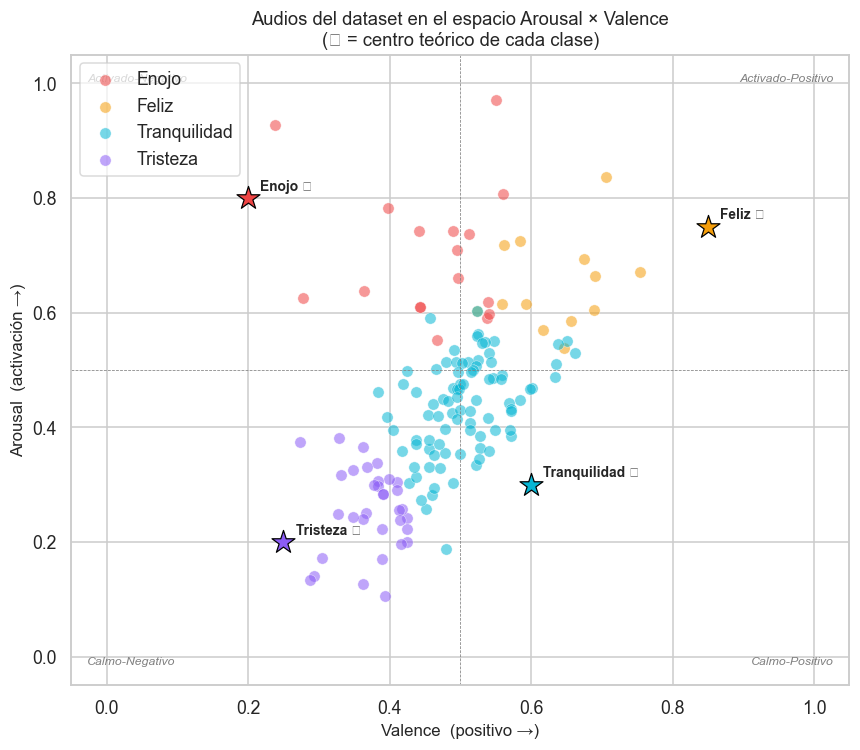

In [9]:
# ── Circumplex: Arousal × Valence ──────────────────────────────────────────
EMOTION_CENTERS = {
    "Enojo":        (0.80, 0.20),
    "Feliz":        (0.75, 0.85),
    "Tranquilidad": (0.30, 0.60),
    "Tristeza":     (0.20, 0.25),
}

fig, ax = plt.subplots(figsize=(8, 7))
for clase in ACTIVE_CLASSES:
    sub = df_audit[df_audit["clase_etiqueta"] == clase]
    ax.scatter(sub["valence"], sub["arousal"],
               c=PALETTE[clase], label=clase, alpha=0.55, s=55,
               edgecolors="white", linewidths=0.4)

for clase, (a, v) in EMOTION_CENTERS.items():
    ax.scatter(v, a, c=PALETTE[clase], s=250, marker="*",
               edgecolors="black", linewidths=0.8, zorder=6)
    ax.annotate(f"{clase} ★", (v, a), textcoords="offset points",
                xytext=(8, 5), fontsize=9, fontweight="bold")

ax.set_xlabel("Valence  (positivo →)", fontsize=11)
ax.set_ylabel("Arousal  (activación →)", fontsize=11)
ax.set_title("Audios del dataset en el espacio Arousal × Valence\n(★ = centro teórico de cada clase)", fontsize=12)
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.legend(framealpha=0.7, loc="upper left")
ax.axhline(0.5, color="gray", lw=0.5, ls="--")
ax.axvline(0.5, color="gray", lw=0.5, ls="--")
for txt, (xa, ya, ha, va) in [
    ("Activado-Negativo", (0.02, 0.97, "left", "top")),
    ("Activado-Positivo", (0.98, 0.97, "right", "top")),
    ("Calmo-Negativo",    (0.02, 0.03, "left", "bottom")),
    ("Calmo-Positivo",    (0.98, 0.03, "right", "bottom")),
]:
    ax.text(xa, ya, txt, va=va, ha=ha, fontsize=8, color="gray",
            transform=ax.transAxes, style="italic")
plt.tight_layout()
plt.show()

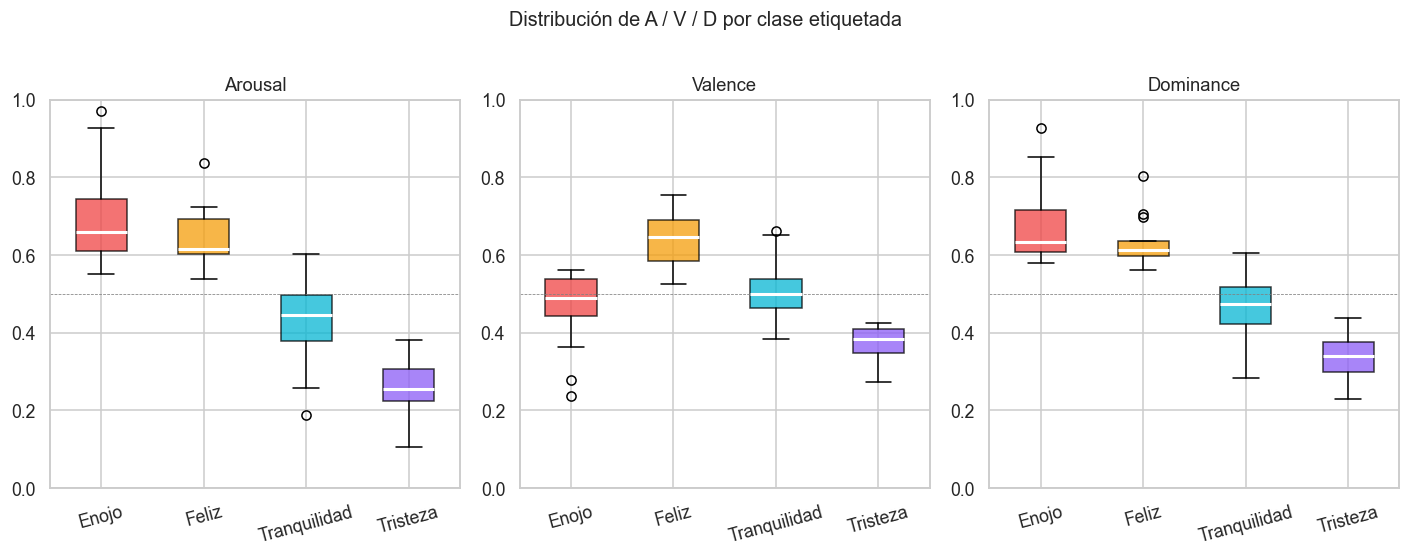

In [10]:
# ── Box plots A / V / D por clase ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, (col, label) in zip(axes, [("arousal", "Arousal"), ("valence", "Valence"), ("dominance", "Dominance")]):
    data = [df_audit[df_audit["clase_etiqueta"] == c][col].dropna().values for c in ACTIVE_CLASSES]
    bps = ax.boxplot(data, patch_artist=True, labels=ACTIVE_CLASSES, widths=0.5,
                     medianprops=dict(color="white", lw=2))
    for patch, clase in zip(bps["boxes"], ACTIVE_CLASSES):
        patch.set_facecolor(PALETTE[clase]); patch.set_alpha(0.75)
    ax.set_title(label, fontsize=12); ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=15)
    ax.axhline(0.5, color="gray", lw=0.5, ls="--")

plt.suptitle("Distribución de A / V / D por clase etiquetada", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# ── Audios sospechosos (delta > 0) ────────────────────────────────────────
sosp = df_audit[df_audit["delta"] > 0].sort_values("delta", ascending=False).reset_index(drop=True)
print(f"Audios donde el modelo SER prefiere otra clase: {len(sosp)} / {len(df_audit)}")
print(f"  Sospechosos fuertes (delta > 0.15): {(sosp['delta'] > 0.15).sum()}")
cols = ["archivo", "clase_etiqueta", "suena_a", "delta", "score_propio", "score_suena_a",
        "arousal", "valence", "dominance"]
display(sosp[cols].head(15).style.background_gradient(subset=["delta"], cmap="Reds").format(precision=3))

Audios donde el modelo SER prefiere otra clase: 11 / 161
  Sospechosos fuertes (delta > 0.15): 1


,archivo,clase_etiqueta,suena_a,delta,score_propio,score_suena_a,arousal,valence,dominance
0,VA_13_ENO.mpeg,Enojo,Tranquilidad,0.184,0.187,0.371,0.552,0.467,0.586
1,VZ_05_FEL.ogg,Feliz,Tranquilidad,0.133,0.335,0.468,0.539,0.646,0.562
2,ED_01_ENO_S.ogg,Enojo,Tranquilidad,0.131,0.179,0.310,0.590,0.538,0.608
3,MT_05_ENO.ogg,Enojo,Tranquilidad,0.128,0.173,0.301,0.597,0.540,0.591
4,SG_02_FEL.ogg,Feliz,Tranquilidad,0.077,0.201,0.278,0.603,0.524,0.605
5,VA_04_TRI.ogg,Tristeza,Tranquilidad,0.067,0.600,0.668,0.305,0.410,0.380
6,ED_03_FEL.ogg,Feliz,Tranquilidad,0.053,0.334,0.387,0.570,0.617,0.567
7,MT_02_ENO.ogg,Enojo,Tranquilidad,0.034,0.211,0.245,0.618,0.539,0.616
8,MT_10_TRI.ogg,Tristeza,Tranquilidad,0.010,0.635,0.645,0.290,0.410,0.364
9,VZ_02_TRI.ogg,Tristeza,Tranquilidad,0.008,0.598,0.606,0.337,0.382,0.386


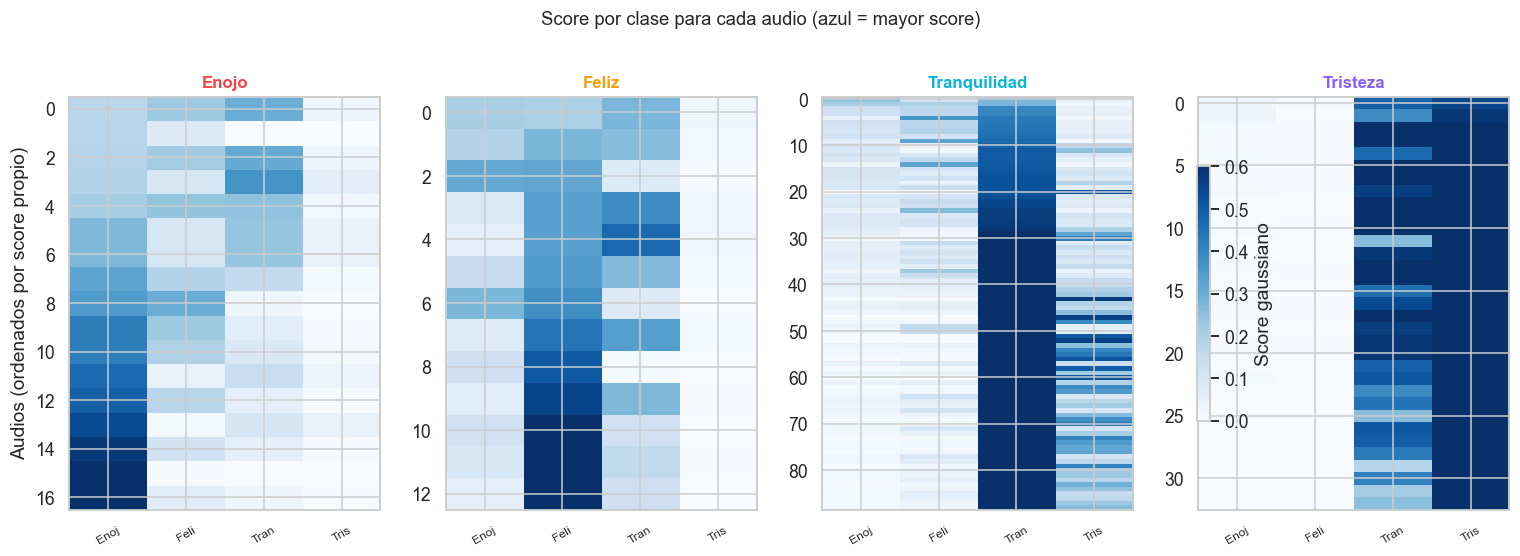

In [12]:
# ── Heatmap: score de cada audio para cada clase ──────────────────────────
score_cols = [f"score_{c}" for c in ACTIVE_CLASSES]
missing = [c for c in score_cols if c not in df_audit.columns]
if missing:
    # columnas con nombre distinto (minúsculas sin acento)
    score_cols = [c for c in df_audit.columns if c.startswith("score_") and c != "score_propio" and c != "score_suena_a"]

fig, axes = plt.subplots(1, len(ACTIVE_CLASSES), figsize=(14, 5), sharey=False)
for ax, clase in zip(axes, ACTIVE_CLASSES):
    sub = df_audit[df_audit["clase_etiqueta"] == clase].sort_values("score_propio").reset_index(drop=True)
    mat = sub[score_cols].values
    im = ax.imshow(mat, aspect="auto", vmin=0, vmax=0.6, cmap="Blues")
    ax.set_title(clase, fontsize=11, color=PALETTE[clase], fontweight="bold")
    ax.set_xticks(range(len(ACTIVE_CLASSES)))
    ax.set_xticklabels([c.replace("score_", "")[:4] for c in score_cols], fontsize=8, rotation=30)
    ax.set_ylabel("Audios (ordenados por score propio)" if ax == axes[0] else "")

plt.suptitle("Score por clase para cada audio (azul = mayor score)", fontsize=12, y=1.01)
plt.colorbar(im, ax=axes, shrink=0.6, label="Score gaussiano")
plt.tight_layout()
plt.show()

---
## 2. Localización de segmentos

`segmentar_rescate.py` aplica una **ventana deslizante de 10 s** sobre cada audio completo, puntúa cada ventana con el modelo SER para la clase declarada, y guarda el tramo de mayor score como archivo `.wav`.

**Por qué esto no es cherry-picking:** se conservan *todos* los audios; solo se elige *qué 10 s* de cada uno usar en entrenamiento. El holdout nunca se segmenta.

Estados posibles por audio:
- **OK** — los primeros 10 s ya suenan a la clase correcta
- **RESCATADO** — otra ventana tiene un score más alto para la clase correcta
- **SIN_RESCATE** — ninguna ventana supera el umbral → probablemente mal etiquetado

> ⏱ Primera ejecución: ~30-60 min (usa el mismo encoder que la auditoría).

In [13]:
run("scripts/segmentar_rescate.py", output_check=SEG_CSV)

► /Users/apple/Desktop/Universidad/Machine Learning/.venv/bin/python /Users/apple/Desktop/Universidad/Machine Learning/clasificador-audios/scripts/segmentar_rescate.py
Cargando audeering/wav2vec2-large-robust-12-ft-emotion-msp-dim ...


Loading weights: 100%|██████████| 234/234 [00:00<00:00, 7961.35it/s]


  Modelo cargado en 3.5s sobre mps
  Ventana=10.0s  paso=5.0s  umbral rescate=0.45

>>> Enojo: 17 audios
    ED_01_ENO_S.ogg        SIN_RESCATE full=0.18(Tran) best=0.31(Enoj) @[5-15s]
    ED_01_FEL.ogg          OK          full=0.42(Enoj) best=0.49(Enoj) @[5-15s]
    ED_02_ENO_S.ogg        OK          full=0.42(Enoj) best=0.53(Enoj) @[5-15s]
    ED_03_ENO_S.ogg        OK          full=0.35(Enoj) best=0.82(Enoj) @[5-15s]
    ED_04_ENO_S.ogg        OK          full=0.18(Enoj) best=0.81(Enoj) @[20-30s]
    ED_05_ENO_S.ogg        OK          full=0.72(Enoj) best=0.72(Enoj) @[0-10s]
    MT_02_ENO.ogg          RESCATADO   full=0.21(Tran) best=0.70(Enoj) @[5-15s]
    MT_03_ENO.ogg          OK          full=0.58(Enoj) best=0.58(Enoj) @[0-10s]
    MT_05_ENO.ogg          SIN_RESCATE full=0.17(Tran) best=0.43(Enoj) @[10-20s]
    MT_10_ENO.ogg          OK          full=0.49(Enoj) best=0.49(Enoj) @[0-10s]
    SG_01_ENO.ogg          OK          full=0.27(Enoj) best=0.27(Enoj) @[0-10s]
    SG_01_FEL

Note: Illegal Audio-MPEG-Header 0x362c2032 at offset 1263360.
Note: Trying to resync...
Note: Skipped 1024 bytes in input.
[src/libmpg123/parse.c:wetwork():1349] error: Giving up resync after 1024 bytes - your stream is not nice... (maybe increasing resync limit could help).


    VA_13_ENO.mpeg         SIN_RESCATE full=0.17(Tran) best=0.17(Tran) @[0-10s]
    VZ_02_ENO.ogg          OK          full=0.71(Enoj) best=0.94(Enoj) @[10-20s]
    VZ_03_FEL.ogg          OK          full=0.54(Enoj) best=0.54(Enoj) @[0-10s]

>>> Feliz: 13 audios
    ED_02_FEL.ogg          OK          full=0.66(Feli) best=0.66(Feli) @[0-10s]
    ED_03_FEL.ogg          RESCATADO   full=0.33(Tran) best=0.67(Feli) @[10-20s]
    ED_04_FEL.ogg          OK          full=0.28(Feli) best=0.29(Feli) @[20-30s]
    MT_01_FEL.ogg          OK          full=0.35(Feli) best=0.40(Feli) @[5-15s]
    MT_03_FEL.ogg          OK          full=0.38(Feli) best=0.70(Feli) @[15-25s]
    SG_02_FEL.ogg          SIN_RESCATE full=0.20(Tran) best=0.20(Tran) @[0-10s]
    SG_04_TRA.ogg          OK          full=0.65(Feli) best=0.65(Feli) @[0-10s]
    VZ_04_FEL.mp4          OK          full=0.44(Feli) best=0.44(Feli) @[0-10s]
    VZ_05_FEL.ogg          RESCATADO   full=0.34(Tran) best=0.50(Feli) @[20-30s]
    VZ_06_FEL

Note: Illegal Audio-MPEG-Header 0x2c203333 at offset 1445760.
Note: Trying to resync...
Note: Skipped 1024 bytes in input.
[src/libmpg123/parse.c:wetwork():1349] error: Giving up resync after 1024 bytes - your stream is not nice... (maybe increasing resync limit could help).


    VA_13_FE.mpeg          OK          full=0.60(Tran) best=0.77(Tran) @[20-30s]


Note: Illegal Audio-MPEG-Header 0x31363232 at offset 1818240.
Note: Trying to resync...
Note: Skipped 1024 bytes in input.
[src/libmpg123/parse.c:wetwork():1349] error: Giving up resync after 1024 bytes - your stream is not nice... (maybe increasing resync limit could help).


    VA_13_TRI.mpeg         OK          full=0.78(Tran) best=0.90(Tran) @[10-20s]
    VA_14_TRI.ogg          OK          full=0.64(Tran) best=0.82(Tran) @[30-40s]
    VA_15_FE.mp4           OK          full=0.77(Tran) best=0.79(Tran) @[15-25s]
    VZ_01_ENO.mp4          OK          full=0.50(Tran) best=0.76(Tran) @[20-30s]
    VZ_01_FEL.ogg          OK          full=0.65(Tran) best=0.78(Tran) @[17-27s]
    VZ_01_TRA.mp4          OK          full=0.72(Tran) best=0.89(Tran) @[25-35s]
    VZ_03_ENO.ogg          OK          full=0.63(Tran) best=0.71(Tran) @[15-25s]
    VZ_03_TRA.ogg          OK          full=0.62(Tran) best=0.71(Tran) @[20-30s]
    VZ_03_TRI.ogg          OK          full=0.57(Tran) best=0.74(Tran) @[26-36s]
    VZ_04_ENO.ogg          OK          full=0.60(Tran) best=0.60(Tran) @[0-10s]
    VZ_05_ENO.ogg          OK          full=0.57(Tran) best=0.57(Tran) @[0-10s]
    VZ_05_TRA.ogg          OK          full=0.73(Tran) best=0.83(Tran) @[20-30s]
    VZ_05_TRI.ogg          OK 

In [14]:
# ── Copiar segmentos a data/procesado/ (lo que lee entrenar_procesado.py) ──
if PROC_DIR.exists() and any(PROC_DIR.rglob("*.wav")):
    n = sum(1 for _ in PROC_DIR.rglob("*.wav"))
    print(f"✓ data/procesado/ ya existe con {n} archivos WAV")
elif SEG_DIR.exists() and any(SEG_DIR.rglob("*.wav")):
    print("Copiando segmentos desde outputs/mejores_segmentos/ → data/procesado/ ...")
    for clase_dir in sorted(SEG_DIR.iterdir()):
        if not clase_dir.is_dir():
            continue
        dest = PROC_DIR / clase_dir.name
        dest.mkdir(parents=True, exist_ok=True)
        for wav in sorted(clase_dir.glob("*.wav")):
            shutil.copy2(wav, dest / wav.name)
    n = sum(1 for _ in PROC_DIR.rglob("*.wav"))
    print(f"✓ Copiados {n} archivos a data/procesado/")
else:
    print("⚠ Correr primero la celda anterior (segmentar_rescate.py)")

✓ data/procesado/ ya existe con 146 archivos WAV


In [15]:
df_seg = pd.read_csv(SEG_CSV)
print(f"Audios procesados: {len(df_seg)}")
print(df_seg.groupby(["clase", "estado"]).size().unstack(fill_value=0))
print(f"\nMejora media de score (best_seg - score_full): {df_seg['mejora'].mean():.3f}")

Audios procesados: 152
estado        OK  RESCATADO  SIN_RESCATE
clase                                   
Enojo         13          1            3
Feliz         10          2            1
Tranquilidad  89          0            0
Tristeza      29          3            1

Mejora media de score (best_seg - score_full): 0.089


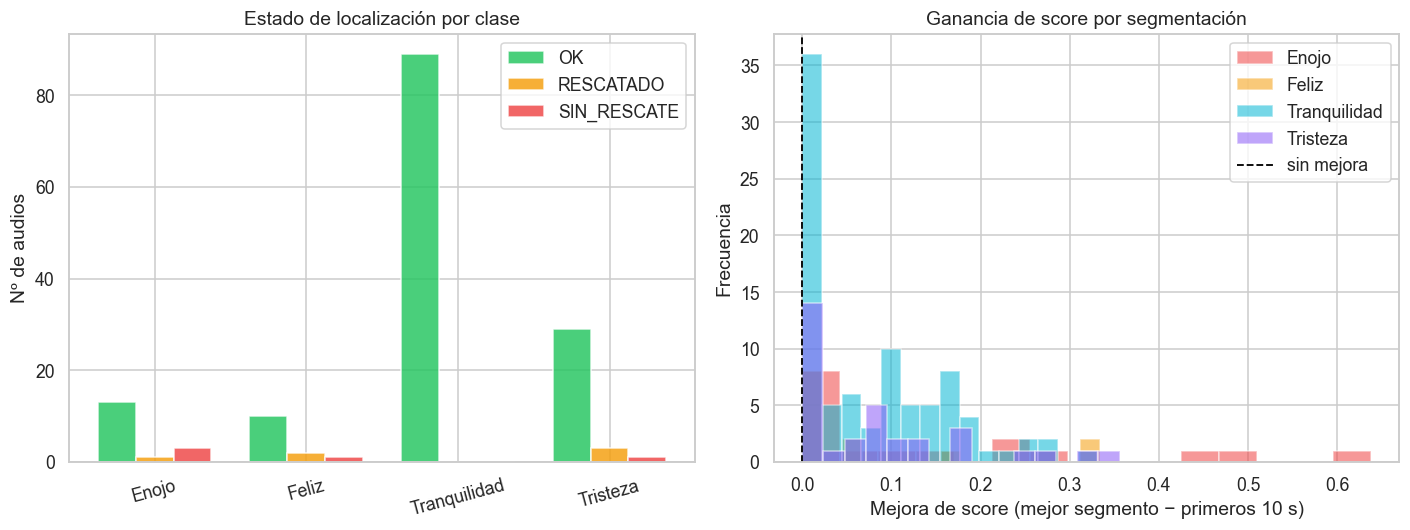

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Izq: distribución de estados por clase
ax = axes[0]
estados = ["OK", "RESCATADO", "SIN_RESCATE"]
colores_estado = {"OK": "#22c55e", "RESCATADO": "#f59e0b", "SIN_RESCATE": "#ef4444"}
x = np.arange(len(ACTIVE_CLASSES)); width = 0.25
for i, est in enumerate(estados):
    vals = [df_seg[(df_seg["clase"] == c) & (df_seg["estado"] == est)].shape[0] for c in ACTIVE_CLASSES]
    bars = ax.bar(x + i * width, vals, width, label=est, color=colores_estado[est], alpha=0.82)
ax.set_xticks(x + width); ax.set_xticklabels(ACTIVE_CLASSES, rotation=15)
ax.set_ylabel("Nº de audios"); ax.set_title("Estado de localización por clase")
ax.legend()

# Der: histograma de mejoras de score
ax = axes[1]
for clase in ACTIVE_CLASSES:
    sub = df_seg[df_seg["clase"] == clase]["mejora"]
    ax.hist(sub, bins=15, alpha=0.55, color=PALETTE[clase], label=clase, edgecolor="white")
ax.axvline(0, color="black", lw=1.2, ls="--", label="sin mejora")
ax.set_xlabel("Mejora de score (mejor segmento − primeros 10 s)")
ax.set_ylabel("Frecuencia")
ax.set_title("Ganancia de score por segmentación")
ax.legend()

plt.tight_layout()
plt.show()

---
## 3. Exploración del dataset localizado

El dataset de entrenamiento (`data/procesado/`) contiene un recorte de 10 s por audio, organizado por clase. Aquí se muestra la distribución de segmentos por clase y por recolector.

In [17]:
# ── Inventario de data/procesado/ ─────────────────────────────────────────
registros = []
if PROC_DIR.exists():
    for clase_dir in sorted(PROC_DIR.iterdir()):
        if not clase_dir.is_dir():
            continue
        for wav in sorted(clase_dir.glob("*.wav")):
            registros.append({"clase": clase_dir.name, "archivo": wav.name,
                               "recolector": wav.name[:2]})
else:
    print("⚠ data/procesado/ no existe. Correr los pasos anteriores.")

df_proc = pd.DataFrame(registros)
print(f"Total segmentos: {len(df_proc)}")
print(df_proc["clase"].value_counts().rename("count").to_frame())

Total segmentos: 146
              count
clase              
Tranquilidad     89
Tristeza         33
Enojo            13
Feliz            11


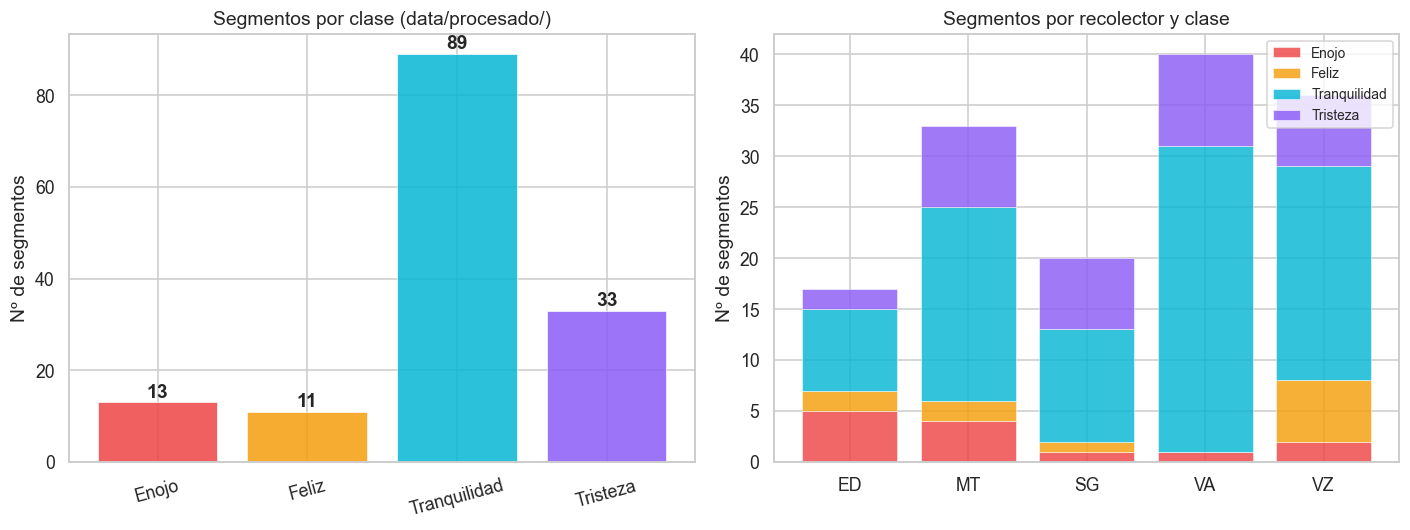

In [18]:
if df_proc.empty:
    print("Sin datos para graficar.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Izq: por clase
    ax = axes[0]
    cnt = df_proc["clase"].value_counts().reindex(ACTIVE_CLASSES, fill_value=0)
    bars = ax.bar(cnt.index, cnt.values, color=[PALETTE.get(c, "gray") for c in cnt.index],
                  edgecolor="white", linewidth=0.5, alpha=0.85)
    for bar, v in zip(bars, cnt.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(v),
                ha="center", va="bottom", fontweight="bold")
    ax.set_title("Segmentos por clase (data/procesado/)")
    ax.set_ylabel("Nº de segmentos")
    ax.tick_params(axis="x", rotation=15)

    # Der: por recolector y clase (stacked bar)
    ax = axes[1]
    pivot = df_proc.groupby(["recolector", "clase"]).size().unstack(fill_value=0)
    bottom = np.zeros(len(pivot))
    for clase in ACTIVE_CLASSES:
        if clase in pivot.columns:
            vals = pivot[clase].values.astype(float)
            ax.bar(pivot.index, vals, bottom=bottom, label=clase,
                   color=PALETTE[clase], alpha=0.82, edgecolor="white", linewidth=0.4)
            bottom += vals
    ax.set_title("Segmentos por recolector y clase")
    ax.set_ylabel("Nº de segmentos")
    ax.legend(loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.show()

---
## 4. Entrenamiento y evaluación honesta

`entrenar_procesado.py` entrena los 6 clasificadores con **leave-one-audio-out honesto**:
- **Train:** embeddings de los segmentos localizados de los *otros* audios
- **Test:** embedding del **audio crudo** (primeros 10 s) del audio dejado fuera

El audio de test nunca se segmenta → no hay leakage. Si la balanced accuracy en "segmentos" sube pero la "honesta" no, la segmentación infló los números.

Con `--guardar` serializa los 6 `.joblib` para la app. Con `--loco` agrega leave-one-collector-out.

> ⏱ Primera ejecución: ~10-20 min (extrae embeddings si no hay cache).

In [19]:
run("scripts/entrenar_procesado.py", "--guardar", "--loco", output_check=EMBED_NPZ)

✓ Ya existe: proc_embeddings.npz  —  saltando (FORCE_RERUN=False)


In [20]:
import json

with open(METRICS_JSON, encoding="utf-8") as f:
    metrics = json.load(f)

print(f"Clases activas : {metrics['active_classes']}")
print(f"Dataset (train): {metrics['dataset_size_train']} segmentos")
print(f"Holdout explorador: {metrics['holdout_dashboard']} audios reservados")
print(f"Chance baseline: {metrics['chance_accuracy']}")
print(f"Mejor modelo   : {metrics['best_model']}")
print()

rows = []
for key, info in metrics["models"].items():
    row = {"Modelo": info["label"],
           "Bal. Acc. honesta": info["balanced_accuracy"],
           "Bal. Acc. sobre segmentos": info.get("balanced_accuracy_loocv_seg", "-")}
    for clase, rec in info.get("recall_por_clase", {}).items():
        row[f"Recall {clase[:4]}"] = rec
    rows.append(row)

df_metrics = pd.DataFrame(rows).set_index("Modelo")
display(df_metrics.sort_values("Bal. Acc. honesta", ascending=False)
        .style.background_gradient(subset=["Bal. Acc. honesta"], cmap="Greens")
        .format(precision=3))

Clases activas : ['Enojo', 'Feliz', 'Tranquilidad', 'Tristeza']
Dataset (train): 116 segmentos
Holdout explorador: 30 audios reservados
Chance baseline: 0.25
Mejor modelo   : logreg



,Bal. Acc. honesta,Bal. Acc. sobre segmentos,Recall Enoj,Recall Feli,Recall Tran,Recall Tris
Modelo,,,,,,
Reg. Logística,0.856,0.979,0.769,0.818,0.865,0.970
SVM lineal,0.855,0.959,0.846,0.727,0.876,0.970
SVM RBF,0.841,0.928,0.846,0.636,0.910,0.970
Random Forest,0.778,0.856,0.692,0.545,0.966,0.909
KNN (k=5),0.725,0.857,0.538,0.636,0.876,0.849
KNN (k=3),0.697,0.777,0.538,0.636,0.854,0.758


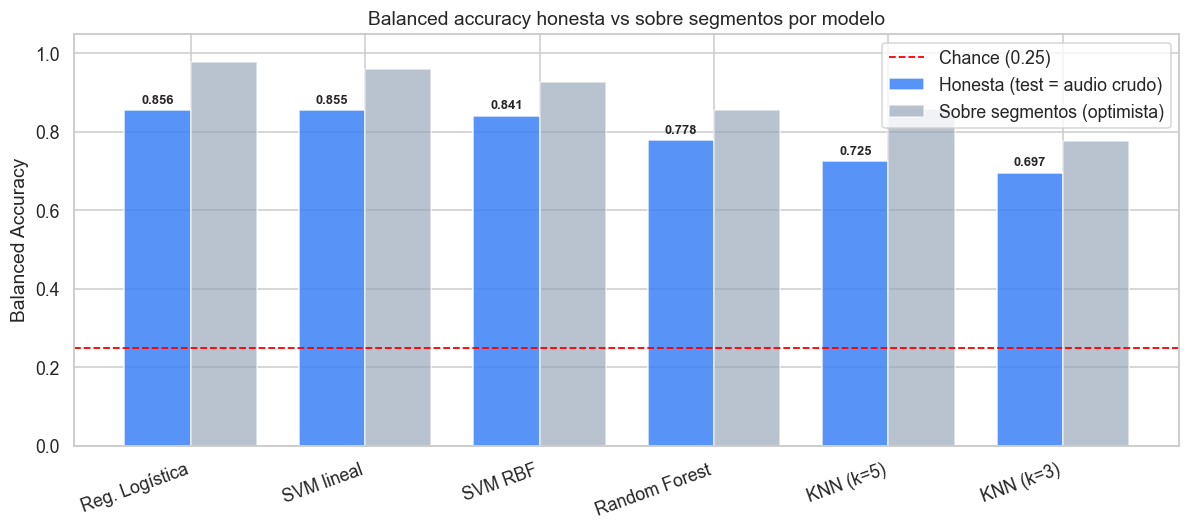

In [21]:
# ── Gráfico comparativo: honesto vs sobre segmentos ───────────────────────
modelos_labels = [metrics["models"][k]["label"] for k in metrics["models"]]
bal_honesta = [metrics["models"][k]["balanced_accuracy"] for k in metrics["models"]]
bal_seg = [metrics["models"][k].get("balanced_accuracy_loocv_seg", None) for k in metrics["models"]]

orden = np.argsort(bal_honesta)[::-1]
x = np.arange(len(modelos_labels))

fig, ax = plt.subplots(figsize=(11, 5))
w = 0.38
bars_h = ax.bar(x - w/2, [bal_honesta[i] for i in orden], w,
                label="Honesta (test = audio crudo)", color="#3b82f6", alpha=0.85, edgecolor="white")
if any(b is not None for b in bal_seg):
    bars_s = ax.bar(x + w/2, [bal_seg[i] for i in orden], w,
                    label="Sobre segmentos (optimista)", color="#94a3b8", alpha=0.65, edgecolor="white")

ax.axhline(metrics["chance_accuracy"], color="red", lw=1.2, ls="--", label=f"Chance ({metrics['chance_accuracy']})")
ax.set_xticks(x)
ax.set_xticklabels([modelos_labels[i] for i in orden], rotation=20, ha="right")
ax.set_ylim(0, 1.05); ax.set_ylabel("Balanced Accuracy")
ax.set_title("Balanced accuracy honesta vs sobre segmentos por modelo")
ax.legend()

for bar in bars_h:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")

plt.tight_layout()
plt.show()

---
## 5. Exploración de embeddings (PCA / t-SNE)

Los embeddings de 1024 dims se reducen a 2D para visualizar la separabilidad entre clases. Se usan los **embeddings de segmento** (los que entran al entrenamiento).

- **PCA** — proyección lineal; rápida, preserva varianza global.
- **t-SNE** — proyección no lineal; agrupa puntos similares localmente (puede distorsionar distancias globales).

In [22]:
if not EMBED_NPZ.exists():
    print("⚠ proc_embeddings.npz no existe. Correr el paso de entrenamiento primero.")
else:
    cache = np.load(EMBED_NPZ, allow_pickle=True)
    Xseg  = cache["Xseg"]    # embeddings de segmentos localizados
    Xraw  = cache["Xraw"]    # embeddings de audios crudos
    y     = cache["y"]
    files = cache["files"]

    # Filtrar solo las clases activas
    mask = np.isin(y, ACTIVE_CLASSES)
    Xseg, Xraw, y, files = Xseg[mask], Xraw[mask], y[mask], files[mask]
    print(f"Embeddings cargados: {Xseg.shape}  (dim={Xseg.shape[1]})")
    print(f"Por clase: {dict(zip(*np.unique(y, return_counts=True)))}")

Embeddings cargados: (146, 1024)  (dim=1024)
Por clase: {np.str_('Enojo'): np.int64(13), np.str_('Feliz'): np.int64(11), np.str_('Tranquilidad'): np.int64(89), np.str_('Tristeza'): np.int64(33)}


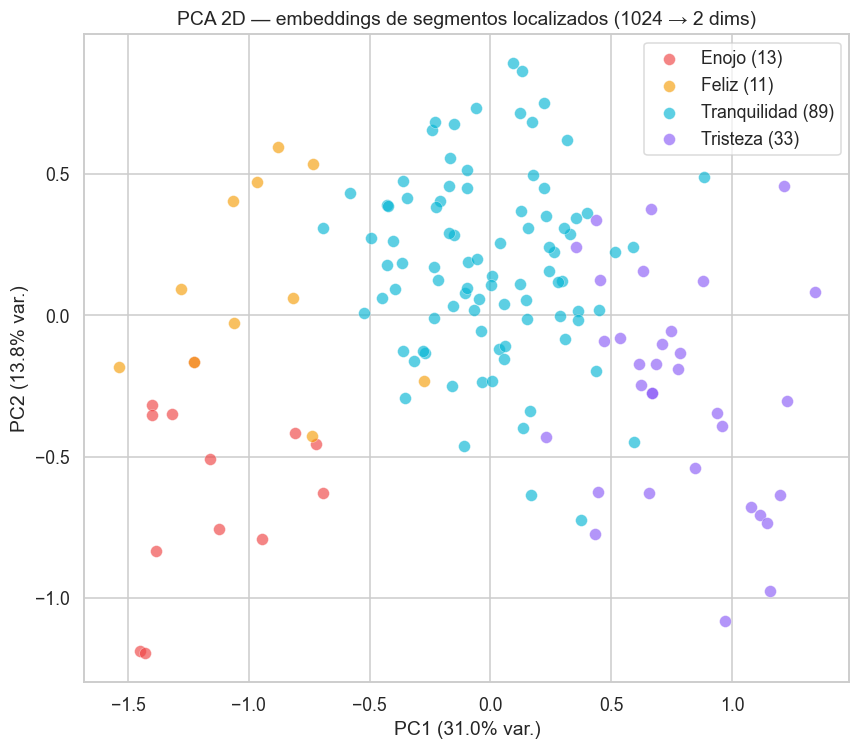

In [23]:
if 'Xseg' not in dir():
    print("Cargar embeddings primero.")
else:
    pca = PCA(n_components=2, random_state=42)
    X2d_pca = pca.fit_transform(Xseg)
    var = pca.explained_variance_ratio_

    fig, ax = plt.subplots(figsize=(8, 7))
    for clase in ACTIVE_CLASSES:
        idx = y == clase
        ax.scatter(X2d_pca[idx, 0], X2d_pca[idx, 1],
                   c=PALETTE[clase], label=f"{clase} ({idx.sum()})",
                   alpha=0.65, s=60, edgecolors="white", linewidths=0.3)
    ax.set_xlabel(f"PC1 ({var[0]:.1%} var.)")
    ax.set_ylabel(f"PC2 ({var[1]:.1%} var.)")
    ax.set_title("PCA 2D — embeddings de segmentos localizados (1024 → 2 dims)")
    ax.legend(framealpha=0.7)
    plt.tight_layout()
    plt.show()

Reduciendo a 50 dims con PCA...
Corriendo t-SNE (esto tarda ~30 s)...


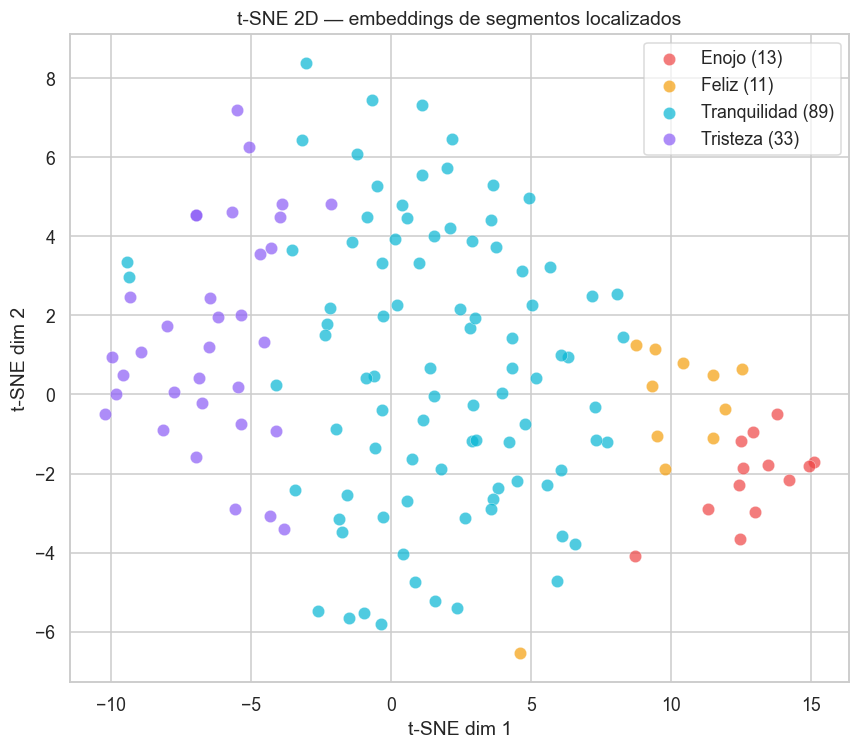

In [25]:
if 'Xseg' not in dir():
    print("Cargar embeddings primero.")
else:
    # Reducir a 50 dims con PCA antes de t-SNE (práctica estándar, acelera y estabiliza)
    print("Reduciendo a 50 dims con PCA...")
    X50 = PCA(n_components=min(50, Xseg.shape[0]-1), random_state=42).fit_transform(Xseg)
    print("Corriendo t-SNE (esto tarda ~30 s)...")
    # sklearn >=1.5 renombró n_iter → max_iter
    tsne = TSNE(n_components=2, perplexity=min(30, len(y)//4), random_state=42, max_iter=1000)
    X2d_tsne = tsne.fit_transform(X50)

    fig, ax = plt.subplots(figsize=(8, 7))
    for clase in ACTIVE_CLASSES:
        idx = y == clase
        ax.scatter(X2d_tsne[idx, 0], X2d_tsne[idx, 1],
                   c=PALETTE[clase], label=f"{clase} ({idx.sum()})",
                   alpha=0.70, s=65, edgecolors="white", linewidths=0.3)
    ax.set_title("t-SNE 2D — embeddings de segmentos localizados")
    ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
    ax.legend(framealpha=0.7)
    plt.tight_layout()
    plt.show()

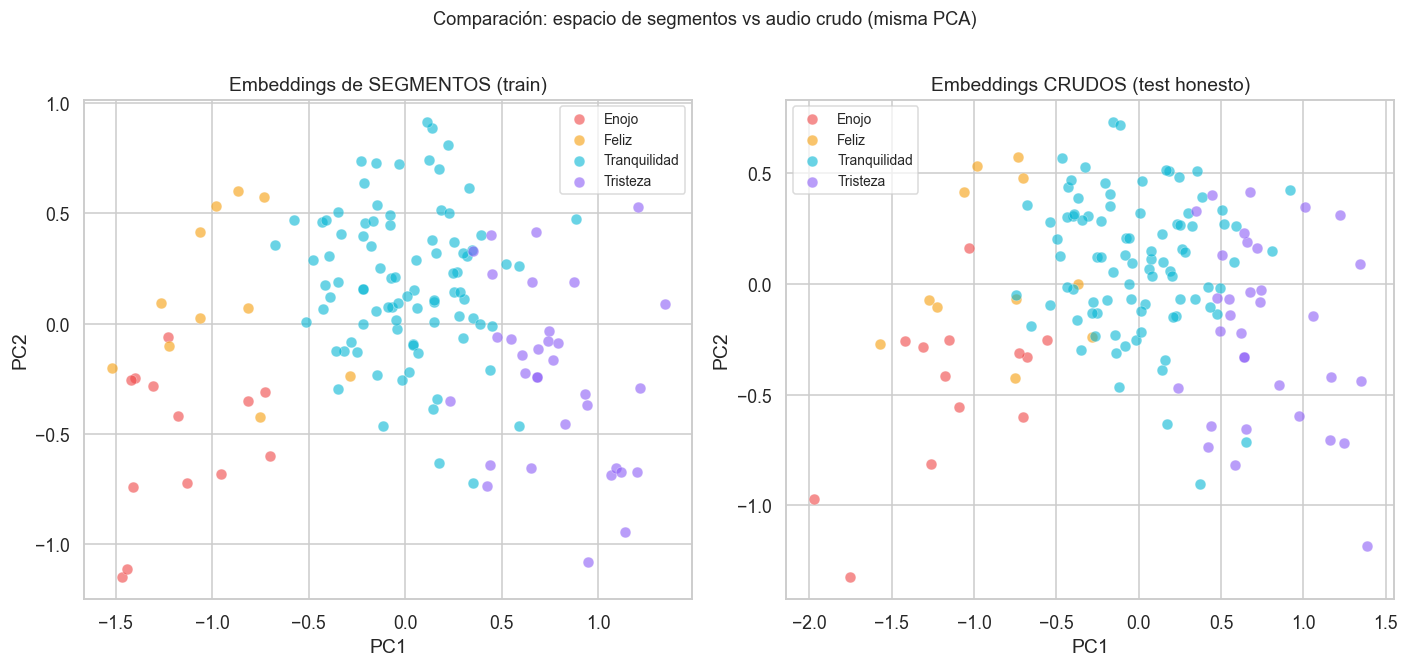

In [26]:
# ── Segmento vs Audio crudo en PCA ────────────────────────────────────────
if 'Xseg' not in dir():
    print("Cargar embeddings primero.")
else:
    pca2 = PCA(n_components=2, random_state=42)
    Xall = np.vstack([Xseg, Xraw])
    X2d_all = pca2.fit_transform(Xall)
    X2d_seg_all, X2d_raw_all = X2d_all[:len(Xseg)], X2d_all[len(Xseg):]

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    for ax, (X2d, title) in zip(axes, [
        (X2d_seg_all, "Embeddings de SEGMENTOS (train)"),
        (X2d_raw_all, "Embeddings CRUDOS (test honesto)"),
    ]):
        for clase in ACTIVE_CLASSES:
            idx = y == clase
            ax.scatter(X2d[idx, 0], X2d[idx, 1], c=PALETTE[clase],
                       label=clase, alpha=0.60, s=50, edgecolors="white", linewidths=0.3)
        ax.set_title(title); ax.legend(fontsize=9, framealpha=0.7)
        ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    plt.suptitle("Comparación: espacio de segmentos vs audio crudo (misma PCA)", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

---
## 6. Evaluación detallada

Matriz de confusión y recall por clase para cada uno de los 6 modelos, calculados con **LOOCV honesto** (train = segmento, test = audio crudo).

> Esta celda re-corre el LOOCV en memoria (~1-3 min) usando los embeddings ya cacheados — no requiere el encoder.

In [27]:
if 'Xseg' not in dir():
    print("⚠ Cargar embeddings primero (celda 'embed-load').")
else:
    from exportar_modelos import MODEL_SPECS
    from sklearn.metrics import balanced_accuracy_score, recall_score
    from sklearn.model_selection import LeaveOneOut

    print("Corriendo LOOCV honesto para los 6 modelos...")
    loo = LeaveOneOut()
    resultados_eval = {}
    for key, spec in MODEL_SPECS.items():
        y_pred = np.empty(len(y), dtype=object)
        for train_idx, test_idx in loo.split(Xseg):
            i = test_idx[0]
            pipe = spec["builder"]()
            pipe.fit(Xseg[train_idx], y[train_idx])
            y_pred[i] = pipe.predict(Xraw[i].reshape(1, -1))[0]
        bal = balanced_accuracy_score(y, y_pred)
        rec = recall_score(y, y_pred, labels=ACTIVE_CLASSES, average=None, zero_division=0)
        resultados_eval[key] = {"label": spec["label"], "bal": bal, "y_pred": y_pred,
                                "recall": dict(zip(ACTIVE_CLASSES, rec))}
        print(f"  {spec['label']:<20} bal_acc={bal:.3f}  rec={dict(zip(ACTIVE_CLASSES, np.round(rec, 3)))}")
    print("\nLOOCV completado.")

Corriendo LOOCV honesto para los 6 modelos...
  SVM lineal           bal_acc=0.855  rec={'Enojo': np.float64(0.846), 'Feliz': np.float64(0.727), 'Tranquilidad': np.float64(0.876), 'Tristeza': np.float64(0.97)}
  Reg. Logística       bal_acc=0.856  rec={'Enojo': np.float64(0.769), 'Feliz': np.float64(0.818), 'Tranquilidad': np.float64(0.865), 'Tristeza': np.float64(0.97)}
  SVM RBF              bal_acc=0.841  rec={'Enojo': np.float64(0.846), 'Feliz': np.float64(0.636), 'Tranquilidad': np.float64(0.91), 'Tristeza': np.float64(0.97)}
  Random Forest        bal_acc=0.778  rec={'Enojo': np.float64(0.692), 'Feliz': np.float64(0.545), 'Tranquilidad': np.float64(0.966), 'Tristeza': np.float64(0.909)}
  KNN (k=5)            bal_acc=0.725  rec={'Enojo': np.float64(0.538), 'Feliz': np.float64(0.636), 'Tranquilidad': np.float64(0.876), 'Tristeza': np.float64(0.848)}
  KNN (k=3)            bal_acc=0.697  rec={'Enojo': np.float64(0.538), 'Feliz': np.float64(0.636), 'Tranquilidad': np.float64(0.854),

In [ ]:
if 'resultados_eval' not in dir():
    print("Correr el LOOCV primero.")
else:
    # ── Matriz de confusión del mejor modelo ─────────────────────────────
    best_key = max(resultados_eval, key=lambda k: resultados_eval[k]["bal"])
    best_pred = resultados_eval[best_key]["y_pred"]
    best_label = resultados_eval[best_key]["label"]

    cm_mat = confusion_matrix(y, best_pred, labels=ACTIVE_CLASSES)
    cm_norm = cm_mat.astype(float) / cm_mat.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, (mat, title, fmt) in zip(axes, [
        (cm_mat, "Conteos", "d"),
        (cm_norm, "Normalizada (recall diagonal)", ".2f"),
    ]):
        sns.heatmap(mat, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=ACTIVE_CLASSES, yticklabels=ACTIVE_CLASSES,
                    linewidths=0.5, linecolor="white", ax=ax)
        ax.set_title(f"CM {title}")
        ax.set_xlabel("Predicho"); ax.set_ylabel("Real")

    plt.suptitle(f"{best_label}  —  bal. acc. honesta = {resultados_eval[best_key]['bal']:.3f}",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

In [ ]:
if 'resultados_eval' not in dir():
    print("Correr el LOOCV primero.")
else:
    # ── Heatmap de recall: modelos × clases ──────────────────────────────
    keys_orden = sorted(resultados_eval, key=lambda k: -resultados_eval[k]["bal"])
    recall_mat = np.array([[resultados_eval[k]["recall"][c] for c in ACTIVE_CLASSES]
                            for k in keys_orden])
    labels_mod = [resultados_eval[k]["label"] for k in keys_orden]
    bals = [resultados_eval[k]["bal"] for k in keys_orden]

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.heatmap(recall_mat, annot=True, fmt=".2f", cmap="RdYlGn",
                vmin=0, vmax=1,
                xticklabels=ACTIVE_CLASSES,
                yticklabels=[f"{l}  ({b:.3f})" for l, b in zip(labels_mod, bals)],
                linewidths=0.4, linecolor="white", ax=ax)
    ax.set_title("Recall por clase × modelo  (LOOCV honesto)\n(etiquetas en eje Y incluyen bal. acc.)",
                 fontsize=11)
    ax.set_xlabel("Clase real")
    plt.tight_layout()
    plt.show()

---
## 7. Generación de datos del dashboard

Estos tres scripts producen los archivos JSON y PNG que consume la app Flask. Se ejecutan en orden:

1. `generar_datos_decisiones.py` → `outputs/decisions_data.json` (simulador de VPN)
2. `build_experiment_history.py` → `outputs/experiment_history.json` (switcher de experimentos)
3. `regenerar_figuras.py` → `outputs/figuras/*.png` (CM + PCA/t-SNE por escenario)

In [ ]:
run("scripts/generar_datos_decisiones.py",
    output_check=OUTPUTS / "decisions_data.json")

run("scripts/build_experiment_history.py",
    output_check=OUTPUTS / "experiment_history.json")

run("scripts/regenerar_figuras.py",
    output_check=OUTPUTS / "figuras")

In [ ]:
# ── Mostrar las figuras generadas inline ─────────────────────────────────
from IPython.display import Image as IPImage

figuras_dir = OUTPUTS / "figuras"
if figuras_dir.exists():
    pngs = sorted(figuras_dir.glob("*.png"))
    print(f"Figuras generadas: {len(pngs)}")
    for p in pngs:
        print(f"  {p.name}")
        display(IPImage(str(p), width=750))
else:
    print("⚠ outputs/figuras/ no existe. Correr la celda anterior.")

---
## 8. Inferencia de ejemplo

Carga el mejor modelo serializado y predice sobre un audio del holdout del dashboard.

Los audios del holdout son los que aparecen en el **Explorador del Dataset** de la app — nunca entraron al training.

In [ ]:
import joblib, librosa
from emotion_encoder import load_encoder, extract_embedding

HOLDOUT_JSON = OUTPUTS / "holdout_dashboard.json"
if not HOLDOUT_JSON.exists():
    print("⚠ holdout_dashboard.json no existe. Correr entrenar_procesado.py --guardar primero.")
else:
    with open(HOLDOUT_JSON, encoding="utf-8") as f:
        holdout = json.load(f)

    print("Audios reservados para el explorador (holdout):")
    for clase, archivos in holdout.items():
        print(f"  {clase}: {len(archivos)} audios")
        for a in archivos[:3]:
            print(f"    {a}")

In [ ]:
if 'holdout' not in dir() or not (OUTPUTS / "modelos").exists():
    print("⚠ Holdout o modelos no disponibles.")
else:
    # Elegir un audio del holdout
    CLASE_TEST = list(holdout.keys())[0]
    ARCHIVO_TEST = holdout[CLASE_TEST][0]
    ruta_test = DATA_DIR / CLASE_TEST / ARCHIVO_TEST

    print(f"Audio de prueba: {CLASE_TEST}/{ARCHIVO_TEST}")
    print(f"Clase real     : {CLASE_TEST}")
    print(f"Cargando encoder...")

    proc, model_enc, device = load_encoder(prefer_mps=True)
    y_audio, sr = librosa.load(str(ruta_test), sr=16000, mono=True, duration=10.0)
    emb = extract_embedding(y_audio, sr, proc, model_enc, device).reshape(1, -1)

    print("\nPredicciones de los 6 modelos:")
    print(f"  {'Modelo':<22}  {'Predicción':<16}  {'P(Enojo)':<10}  {'P(real)':<10}  Correcto")
    print("-" * 80)
    for key, spec in MODEL_SPECS.items():
        pipe = joblib.load(OUTPUTS / "modelos" / f"{key}.joblib")
        pred = pipe.predict(emb)[0]
        proba = pipe.predict_proba(emb)[0]
        clases_ord = list(pipe.named_steps["c"].classes_)
        p_enojo = proba[clases_ord.index("Enojo")] if "Enojo" in clases_ord else float("nan")
        p_real  = proba[clases_ord.index(CLASE_TEST)] if CLASE_TEST in clases_ord else float("nan")
        ok = "✓" if pred == CLASE_TEST else "✗"
        print(f"  {spec['label']:<22}  {pred:<16}  {p_enojo:<10.3f}  {p_real:<10.3f}  {ok}")

---
## Resumen del pipeline

```
data/AUDIOS MACHINE LEARNING/
      │
      ▼  auditar_etiquetas_ia.py
outputs/audios_sospechosos_ia.csv   ← A/V/D + delta + suena_a
      │
      ▼  segmentar_rescate.py
outputs/mejores_segmentos/          ← mejor 10 s por audio
      │  (copiar a data/procesado/)
      ▼
data/procesado/                     ← dataset de entrenamiento
      │
      ▼  entrenar_procesado.py --guardar --loco
outputs/modelos/*.joblib            ← 6 clasificadores
outputs/model_metrics.json          ← balanced accuracy honesta
outputs/proc_embeddings.npz         ← embeddings 1024-d cacheados
      │
      ▼  generar_datos_decisiones.py
      ▼  build_experiment_history.py
      ▼  regenerar_figuras.py
outputs/decisions_data.json
outputs/experiment_history.json
outputs/figuras/*.png
      │
      ▼  python app.py
http://127.0.0.1:5001
```

El mejor modelo es **Regresión Logística** con ~0.86 de balanced accuracy honesta en 4 clases (chance = 0.25).